$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 08/07/2025

# Trabalho da P2

In [139]:
import numpy as np
import random
import math
from statistics import mean, variance, correlation, covariance
from tqdm import tqdm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

In [1]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
rng = np.random.default_rng(seed=4)

# Questão 1
Desenvolva os cálculos para determinar os estimadores (de MV ou MM, você
escolhe) do parâmetro θ para cada uma das distribuições discretas abaixo:

## a) Gamma
Gama(x; k=2, θ), com $$ f_X(x; k,\theta) = \frac{x^{k-1}\,e^{-x/\theta}}{\Gamma(k)\,\theta^k},\quad k>0,\ \theta>0,\ x>0 $$

## b) Exponencial
Exponencial, com $$ f_X(x; \theta) = \frac{1}{\theta}\,e^{-x/\theta},\quad \theta>0,\ x>0 $$

## c) Log-Normal
Log-Normal, com $$ f_X(x; \mu=0,\ \theta) = \frac{1}{x\sqrt{2\pi}\,\theta}\,e^{-\frac{1}{2\theta^2}(\ln x - \mu)^2},\quad \theta>0,\ x>0 $$

# Questão 2
Escolha uma dessas distribuições. Desenvolva os cálculos para determinar as
propriedades amostrais do estimador de θ para a distribuição que você selecionou:

## a) Viés

## b) MSE

## c) Consistência

## d) Eficiência Assintótica

# Questão 3
Vamos agora analisar empiricamente como essas propriedades variam com o
tamanho da amostra. Para isso, assuma um valor populacional para o parâmetro θ e
crie 100 amostras, AA(n)i, i=1,...,n com n=200

Denote por $ \hat{\theta}_{i,j}$ o valor estimado de θ na sub-amostra i, i=1,...,100 usando as primeiras
j observações, j=1,...,200.

In [ ]:
# amostragem
n, n_samples = 200, 100
θ = 2
samples = np.zeros((n_samples, n))

for i in range(n_samples):
    samples[i] = rng.gamma(shape=2, scale=θ, size=n)    

In [45]:
def calcula_estimador(samples, sample_size):
    '''
    Calcula o estimador desenvolvido pelo método dos momentos para cada amostra, utilizando sub-amostras de tamanho sample_size.
    Retorna um vetor de tamanho n_samples
    '''
    if sample_size > samples.shape[1] or sample_size <= 0:
        return np.full(samples.shape[0], np.nan)
    return np.mean(samples[:,:sample_size], axis=1)/2

In [48]:
estimativas = np.zeros((n_samples, 100))
for j in range(1,101):
    estimativas[:,j-1] = calcula_estimador(samples, j)

In [50]:
estimativas.shape

(100, 100)

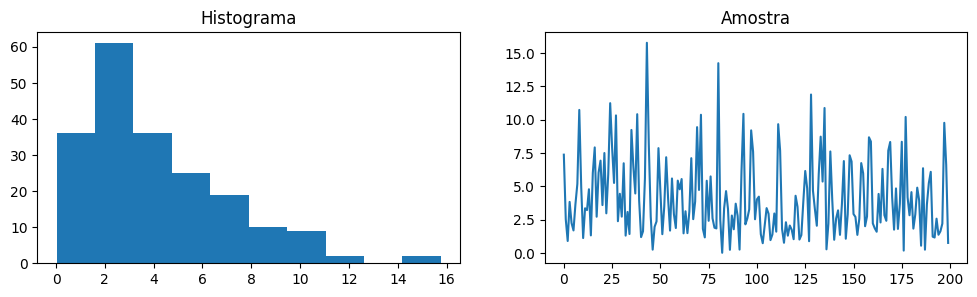

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12,3))

ax[0].hist(samples[0])
ax[0].set_title('Histograma')
ax[1].plot(np.arange(n), samples[0])
ax[1].set_title('Amostra')
plt.show()

## item a)
Defina o viés empírico usando j observações de cada sub-amostra por,
$$
\text{Viés}_{\text{empírico}}(\hat{\theta}_{j}) = \frac{1}{100}\sum_{i=1}^{100} \hat{\theta}_{i,j} - \theta,
$$

e faça um gráfico representando a evolução de $Viés_{empírico}(\hat{\theta}_{i,j})$ contra j.
Comente o resultado com relação ao apresentado na questão 3.

## item b)
Defina o MSE empírico usando j observações de cada sub-amostra por:
$$
\text{MSE}_{\text{empírico}}(\hat{\theta}_{j}) = \frac{1}{100}\sum_{i=1}^{100}\left(\hat{\theta}_{i,j} - \theta\right)^2.
$$
e faça um gráfico representando a evolução de $MSE_{empírico}(\hat{\theta}_{i,j})$ e do 𝑀𝑆𝐸
teórico contra j. Comente o resultado.

## item c)
Usando as 100 sub-amostras, faça um gráfico para evidenciar a consistência
(ou não) do estimador. Justifique suas escolhas com relação ao conceito de
consistência.

## item d)
Construa um intervalo de confiança para o parâmetro, aplique-o para cada sub-
amostra e contabilize o porcentual de vezes que o IC contém o parâmetro de
interesse.

## item e)
Desenvolva um teste de hipóteses para determinar se a proporção observada
no item (e) é igual à prevista (o nível de confiança).

# Questão 4
Crie duas amostras aleatórias independentes de duas distribuições normais de
médias diferentes mas de mesma variância, de tamanhos 100 e 200,
respectivamente.

## item f)
Desenvolva um teste para verificar se as variâncias são iguais.

## item g)
Calcule o p-valor.

## item h) 
Plote a curva característica do teste do item (a) como uma função de $ \lambda = \frac{\sigma^2_1}{\sigma^2_2}$

## item i) 
Determine a probabilidade de erro tipo II do teste do item (a) se a razão entre
as variâncias é $ \frac{\sigma^2_1}{\sigma^2_2} = r$? Escolha r.

## item j) 
Considerando as duas amostras de mesmo tamanho, qual seria o tamanho
mínimo para detectar que $ \frac{\sigma^2_1}{\sigma^2_2} > r$ com pelo menos 90% de probabilidade?

## item k) 
Desenvolva um experimento de simulação para verificar empiricamente
esse resultado.